In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [2]:
import os
import warnings
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    roc_auc_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from IPython.display import display
from google.colab import drive

warnings.filterwarnings('ignore')
print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [3]:
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/PA 3 KEL 10-20260406T061058Z-3-001/PA 3 KEL 10/ML/diabetes_dataset.csv')
print("Dataset berhasil dimuat")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset berhasil dimuat
Jumlah baris: 100000
Jumlah kolom: 16


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


eksplorasi data (EDA)

In [4]:
print("INFORMASI STRUKTUR DATASET")
df.info()
print("\nSTATISTIK DESKRIPTIF")
print(df.describe())
print("\nJUMLAH MISSING VALUE")
print(df.isnull().sum())
print(f"\nTotal keseluruhan missing value di dataset: {df.isnull().sum().sum()}")
print("\nDISTRIBUSI LABEL (KOLOM 'diabetes')")
print(df['diabetes'].value_counts())
print("\nPersentase Distribusi Label:")
print(df['diabetes'].value_counts(normalize=True) * 100)

INFORMASI STRUKTUR DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   1000

In [5]:
print(df.isnull().sum())

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


PENGECEKAN JUMLAH OUTLIER (METODE IQR)
Kolom 'age': 0 baris outlier (0.00%)
Kolom 'bmi': 7086 baris outlier (7.09%)
Kolom 'hbA1c_level': 1315 baris outlier (1.31%)
Kolom 'blood_glucose_level': 2038 baris outlier (2.04%)

VISUALISASI BOXPLOT KOLOM DENGAN OUTLIER


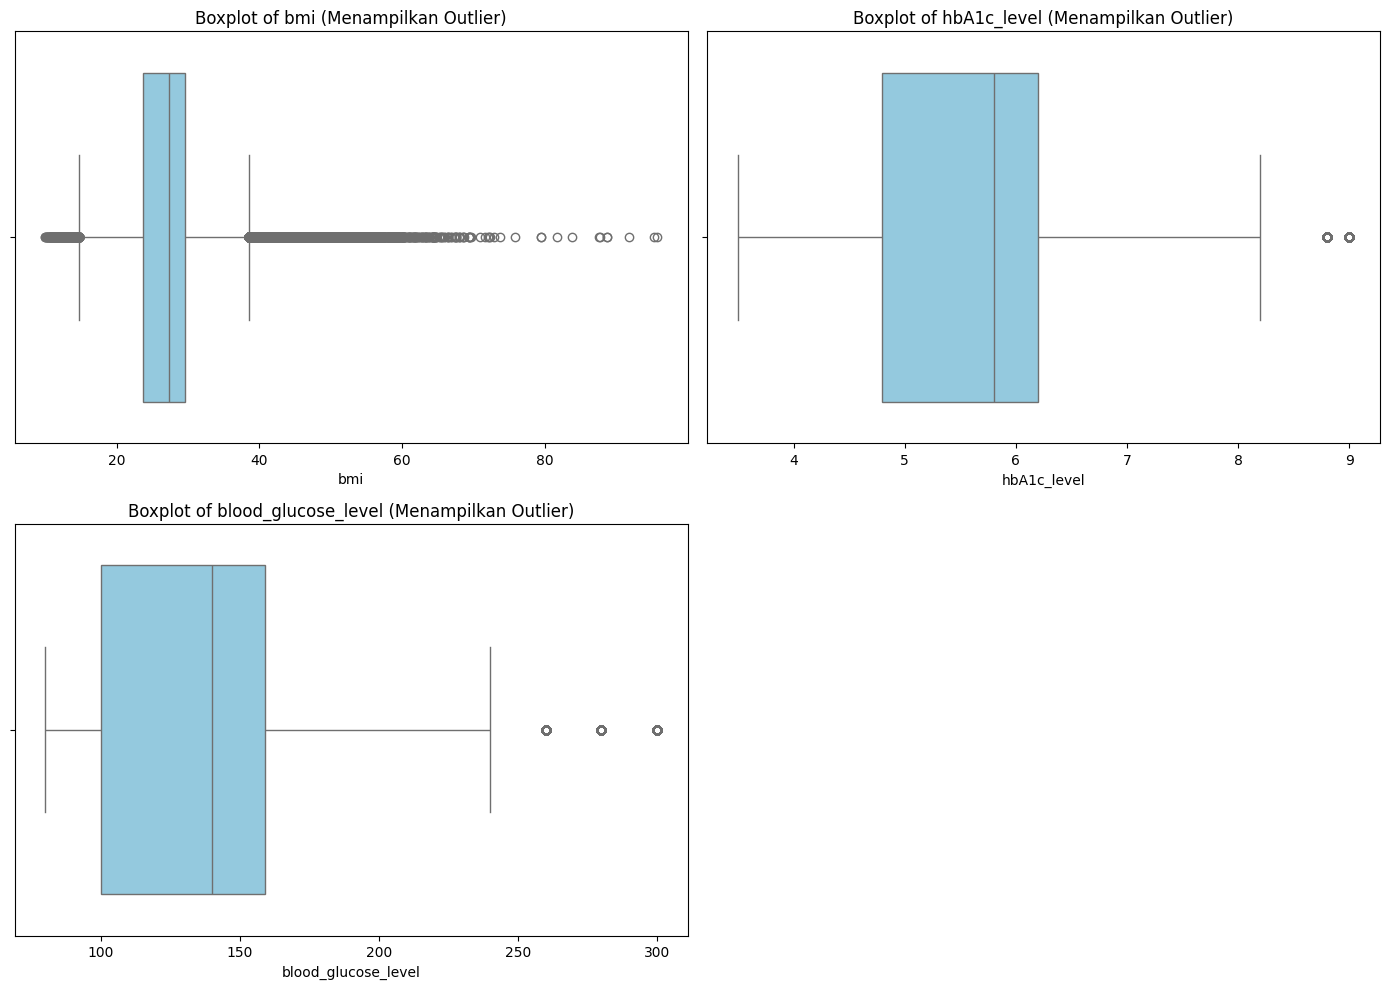

In [6]:
print("PENGECEKAN JUMLAH OUTLIER (METODE IQR)")
outlier_cols = []
numeric_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    #jumlah data outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    print(f"Kolom '{col}': {n_outliers} baris outlier ({pct_outliers:.2f}%)")
    
    if n_outliers > 0:
        outlier_cols.append(col)

print("\nVISUALISASI BOXPLOT KOLOM DENGAN OUTLIER")
if outlier_cols:
    plt.figure(figsize=(14, 10))
    for i, col in enumerate(outlier_cols, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f"Boxplot of {col} (Menampilkan Outlier)", fontsize=12)
        plt.xlabel(col, fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ditemukan kolom numerik yang memiliki outlier.")


DISTRIBUSI LABEL diabetes
diabetes
0    91500
1     8500
Name: count, dtype: int64

Persentase:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


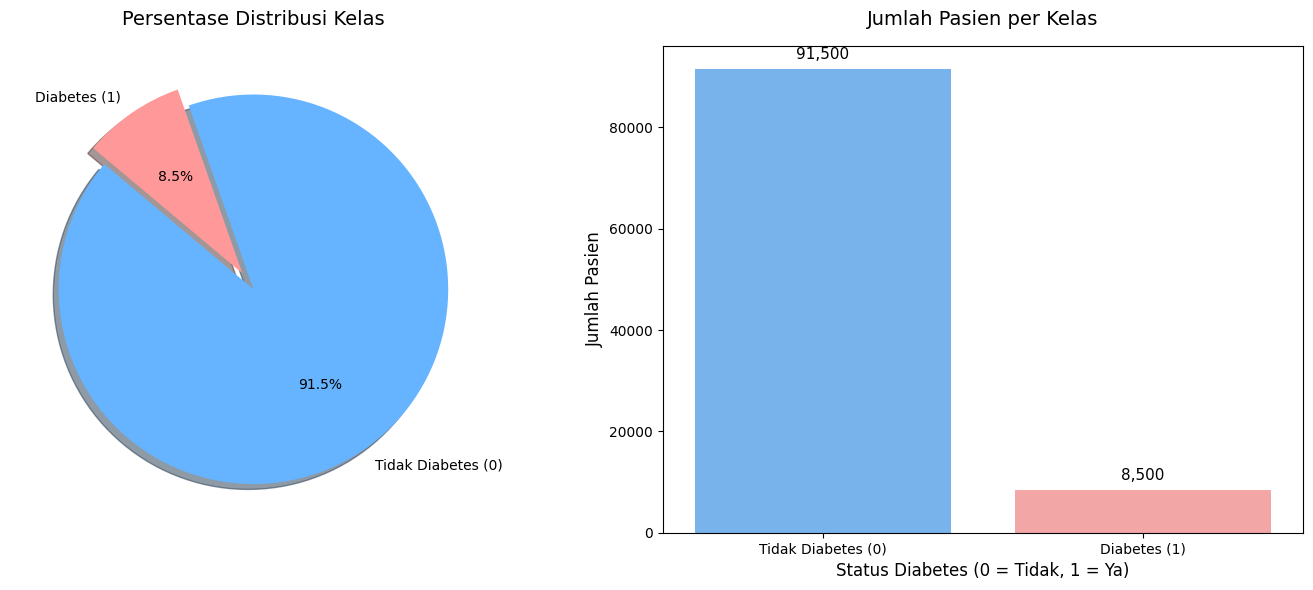

In [7]:
print("DISTRIBUSI LABEL diabetes")
counts = df['diabetes'].value_counts()
print(counts)
print("\nPersentase:")
print(df['diabetes'].value_counts(normalize=True) * 100)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.pie(counts, labels=['Tidak Diabetes (0)', 'Diabetes (1)'], autopct='%1.1f%%', 
        startangle=140, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1), shadow=True)
plt.title("Persentase Distribusi Kelas", fontsize=14, pad=15)

plt.subplot(1, 2, 2)
ax = sns.countplot(x='diabetes', data=df, palette=['#66b3ff', '#ff9999'])
plt.title("Jumlah Pasien per Kelas", fontsize=14, pad=15)
plt.xlabel("Status Diabetes (0 = Tidak, 1 = Ya)", fontsize=12)
plt.ylabel("Jumlah Pasien", fontsize=12)
plt.xticks([0, 1], ['Tidak Diabetes (0)', 'Diabetes (1)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()


KATEGORI RIWAYAT MEROKOK ('smoking_history')
Kategori Unik: ['never' 'not current' 'current' 'No Info' 'ever' 'former']

Jumlah Pasien per Kategori:
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

EKSPLORASI PASIEN ANAK (USIA < 10 TAHUN)
Total pasien anak di bawah 10 tahun: 9762 baris (9.76% dari total dataset)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
12,2015,Female,3.0,Alabama,1,0,0,0,0,0,0,No Info,20.28,3.5,159,0
16,2015,Female,2.0,Alabama,0,1,0,0,0,0,0,never,27.32,3.5,155,0
38,2015,Male,3.0,Alabama,0,0,1,0,0,0,0,never,15.30,4.8,159,0
40,2016,Male,8.0,Alabama,0,1,0,0,0,0,0,never,24.14,6.6,126,0
46,2015,Male,5.0,Alabama,0,0,0,0,1,0,0,No Info,27.32,4.8,130,0


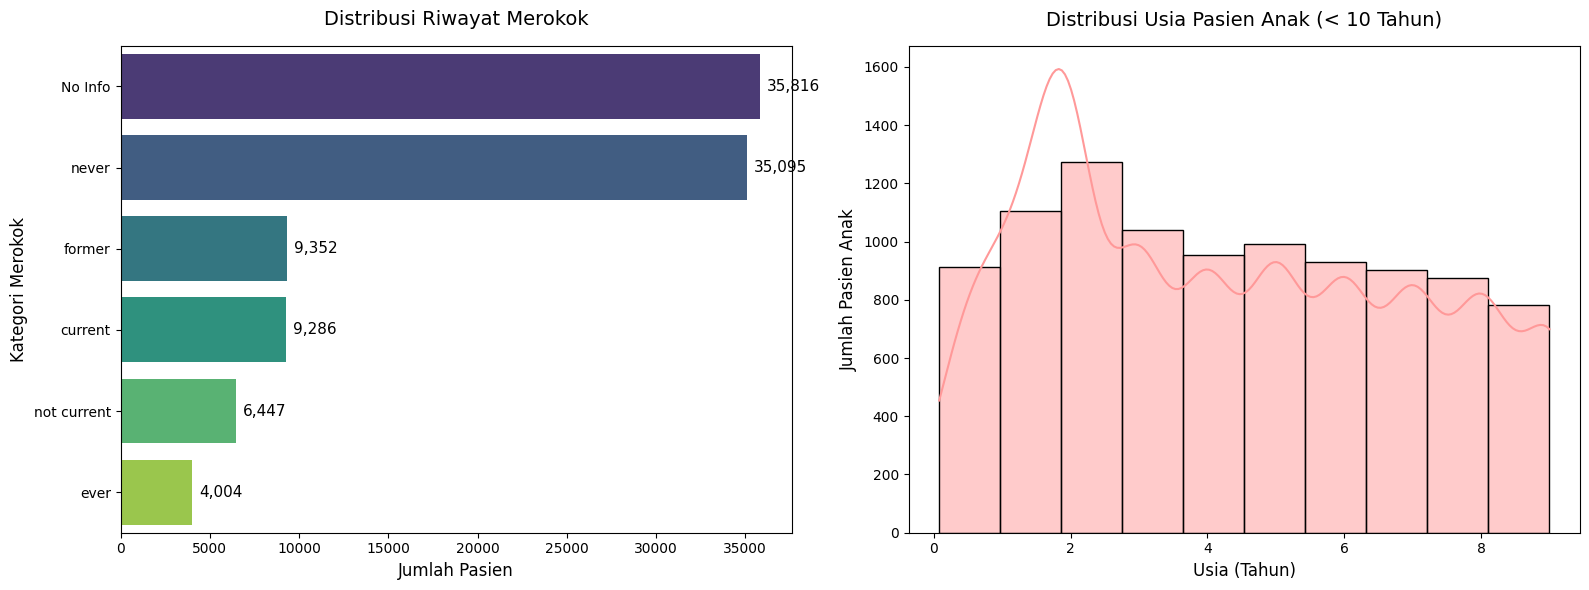

In [8]:
print("KATEGORI RIWAYAT MEROKOK ('smoking_history')")
print("Kategori Unik:", df['smoking_history'].unique())
print("\nJumlah Pasien per Kategori:")
print(df['smoking_history'].value_counts())

print("\nEKSPLORASI PASIEN ANAK (USIA < 10 TAHUN)")
df_kids = df[df['age'] < 10]
print(f"Total pasien anak di bawah 10 tahun: {len(df_kids)} baris ({len(df_kids)/len(df)*100:.2f}% dari total dataset)")
display(df_kids.head())
plt.figure(figsize=(16, 6))

#Bar Chart Riwayat Merokok Keseluruhan
plt.subplot(1, 2, 1)
ax1 = sns.countplot(y='smoking_history', data=df, order=df['smoking_history'].value_counts().index, palette='viridis')
plt.title("Distribusi Riwayat Merokok", fontsize=14, pad=15)
plt.xlabel("Jumlah Pasien", fontsize=12)
plt.ylabel("Kategori Merokok", fontsize=12)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=11, color='black', xytext=(5, 0),
                 textcoords='offset points')

#Distribusi Usia Pasien Anak (< 10 Tahun)
plt.subplot(1, 2, 2)
sns.histplot(df_kids['age'], bins=10, kde=True, color='#ff9999', edgecolor='black')
plt.title("Distribusi Usia Pasien Anak (< 10 Tahun)", fontsize=14, pad=15)
plt.xlabel("Usia (Tahun)", fontsize=12)
plt.ylabel("Jumlah Pasien Anak", fontsize=12)

plt.tight_layout()
plt.show()


# Preprocessing: Noise, Outlier, dan Data Imbalance

Handle Noise mengisi NaN dengan modus:

In [9]:
print("DATA NOISE PADA KOLOM 'gender'")
noise_gender = df[df['gender'] == 'Other']
print(f"Jumlah baris dengan gender 'Other': {len(noise_gender)}")
print("\nDetail baris noise:")
print(noise_gender[['gender', 'age', 'smoking_history', 'diabetes']].to_string())
mode_gender = df[df['gender'] != 'Other']['gender'].mode()[0]
print(f"\nModus gender (yang akan digunakan untuk imputasi): '{mode_gender}'")
df['gender'] = df['gender'].replace('Other', mode_gender)
remaining = (df['gender'] == 'Other').sum()
print(f"\nJumlah 'Other' setelah imputasi : {remaining}")
print(f"Status Imputasi                 : {'BERHASIL' if remaining == 0 else 'GAGAL'}")
print("\nDistribusi gender setelah imputasi:")
print(df['gender'].value_counts())

DATA NOISE PADA KOLOM 'gender'
Jumlah baris dengan gender 'Other': 18

Detail baris noise:
      gender   age smoking_history  diabetes
1611   Other  23.0         No Info         0
2550   Other  19.0         No Info         0
2787   Other  39.0     not current         0
4385   Other  10.0     not current         0
5064   Other  10.0     not current         0
7975   Other  45.0           never         0
19647  Other  47.0           never         0
19658  Other  47.0           never         0
22784  Other  53.0         No Info         0
32002  Other  18.0     not current         0
52722  Other  10.0     not current         0
58482  Other  55.0         No Info         0
59534  Other  26.0     not current         0
64571  Other  19.0         No Info         0
69173  Other  28.0            ever         0
69763  Other  24.0     not current         0
70701  Other   7.0         No Info         0
70863  Other  52.0     not current         0

Modus gender (yang akan digunakan untuk imputasi): 'F

In [10]:
no_info_count = (df['smoking_history'] == 'No Info').sum()

mode_value = df[df['smoking_history'] != 'No Info']['smoking_history'].mode()[0]

print(f"PROSES IMPUTASI KOLOM 'smoking_history")
print(f"Jumlah baris 'No Info' sebelum imputasi : {no_info_count}")
print(f"Modus yang digunakan : '{mode_value}'")

# Melakukan penggantian (imputasi)
df['smoking_history'] = df['smoking_history'].replace('No Info', mode_value)

#Verifikasi setelah imputasi
no_info_remaining = (df['smoking_history'] == 'No Info').sum()
print(f"Jumlah baris 'No Info' setelah imputasi   : {no_info_remaining}")


PROSES IMPUTASI KOLOM 'smoking_history
Jumlah baris 'No Info' sebelum imputasi : 35816
Modus yang digunakan : 'never'
Jumlah baris 'No Info' setelah imputasi   : 0


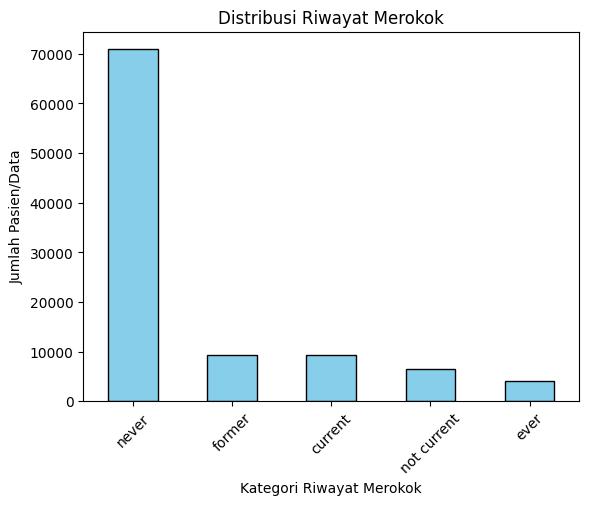

In [11]:
# bar chart dari hasil value_counts
df['smoking_history'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribusi Riwayat Merokok')
plt.xlabel('Kategori Riwayat Merokok')
plt.ylabel('Jumlah Pasien/Data')
plt.xticks(rotation=45)

plt.show()

Handle Outlier (menggunakan IQR pada kolom numerik)

In [12]:
def batasi_nilai_iqr(data, column, min_val=None, max_val=None):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    if min_val is not None:
        lower = max(lower, min_val)
    if max_val is not None:
        upper = min(upper, max_val)

    jumlah_outlier = ((data[column] < lower) | (data[column] > upper)).sum()
    data[column] = data[column].clip(lower=lower, upper=upper)

    print(f" Kolom '{column}'")
    print(f" Batas bawah : {lower:.2f} | Batas atas : {upper:.2f}")
    print(f" Nilai ekstrem yang dibatasi : {jumlah_outlier} baris")
    return data

print("PENANGANAN OUTLIER (PEMBATASAN NILAI / IQR)")
print(f"Jumlah baris sebelum : {len(df)}")
print("-" * 52)

df = batasi_nilai_iqr(df, 'age', min_val=0)
print("-" * 52)

df = batasi_nilai_iqr(df, 'bmi', min_val=10)
print("-" * 52)

df = batasi_nilai_iqr(df, 'hbA1c_level')
print("-" * 52)
df = batasi_nilai_iqr(df, 'blood_glucose_level')
print("-" * 52)

print(f"Jumlah baris sesudah : {len(df)}")
print("Status : SELESAI - Nilai ekstrem berhasil dibatasi")


PENANGANAN OUTLIER (PEMBATASAN NILAI / IQR)
Jumlah baris sebelum : 100000
----------------------------------------------------
 Kolom 'age'
 Batas bawah : 0.00 | Batas atas : 114.00
 Nilai ekstrem yang dibatasi : 0 baris
----------------------------------------------------
 Kolom 'bmi'
 Batas bawah : 14.71 | Batas atas : 38.50
 Nilai ekstrem yang dibatasi : 7086 baris
----------------------------------------------------
 Kolom 'hbA1c_level'
 Batas bawah : 2.70 | Batas atas : 8.30
 Nilai ekstrem yang dibatasi : 1315 baris
----------------------------------------------------
 Kolom 'blood_glucose_level'
 Batas bawah : 11.50 | Batas atas : 247.50
 Nilai ekstrem yang dibatasi : 2038 baris
----------------------------------------------------
Jumlah baris sesudah : 100000
Status : SELESAI - Nilai ekstrem berhasil dibatasi


Handle Data Imbalance dengan metode smote

In [13]:
# Encode kolom kategorikal ke angka
df_encoded = df.copy()
le = LabelEncoder()
kolom_kategorikal = df_encoded.select_dtypes(include=['object']).columns
print("Kolom yang di-encode:", list(kolom_kategorikal))
for col in kolom_kategorikal:
    df_encoded[col] = le.fit_transform(df_encoded[col])
print("Tipe data setelah encoding:")
print(df_encoded.dtypes)
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# distribusi sebelum SMOTE
print("Sebelum SMOTE (data training):")
print(y_train.value_counts())
rasio = y_train.value_counts()[0] / y_train.value_counts()[1]
print("Rasio imbalance : {:.1f}x".format(rasio))
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# distribusi sesudah SMOTE
print("\nSesudah SMOTE (data training):")
print(pd.Series(y_train_smote).value_counts())
print("Status : SELESAI - Kelas sudah seimbang")

Kolom yang di-encode: ['gender', 'location', 'smoking_history']
Tipe data setelah encoding:
year                      int64
gender                    int64
age                     float64
location                  int64
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history           int64
bmi                     float64
hbA1c_level             float64
blood_glucose_level     float64
diabetes                  int64
dtype: object
Sebelum SMOTE (data training):
diabetes
0    73200
1     6800
Name: count, dtype: int64
Rasio imbalance : 10.8x

Sesudah SMOTE (data training):
diabetes
1    73200
0    73200
Name: count, dtype: int64
Status : SELESAI - Kelas sudah seimbang


# Scaling, dan Dimensionality Reduction

Scaling/Normalisasi (StandardScaler untuk numerik)

In [14]:
print(df_encoded.dtypes)

year                      int64
gender                    int64
age                     float64
location                  int64
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history           int64
bmi                     float64
hbA1c_level             float64
blood_glucose_level     float64
diabetes                  int64
dtype: object


In [ ]:
X = df_encoded.drop(columns=['diabetes'])
y = df_encoded['diabetes']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y    
)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  
# PCA (Dimensionality Reduction)
do_pca = True 
if do_pca:
    pca = PCA(n_components=0.95, random_state=42) 
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)  
    
    print(f"PCA Selesai: Fitur berkurang dari {X_train.shape[1]} kolom menjadi {X_train_pca.shape[1]} kolom (Principal Components)")
else:
    X_train_pca = X_train_scaled
    X_test_pca = X_test_scaled
# SMOTE
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train)
print("\nDISTRIBUSI KELAS")
print("Sesudah SMOTE (y_train_final):")
print(y_train_final.value_counts())
print("\nStatus: SELESAI ")

PCA Selesai: Fitur berkurang dari 15 kolom menjadi 13 kolom (Principal Components)

DISTRIBUSI KELAS
Sesudah SMOTE (y_train_final):
diabetes
1    73200
0    73200
Name: count, dtype: int64

Status: SELESAI 


# Modeling

In [16]:
print("MEMULAI PELATIHAN MODEL RANDOM FOREST")
# Inisialisasi Model
rf = RandomForestClassifier(random_state=42)
# Latih model menggunakan data training yang SUDAH di-SMOTE
rf.fit(X_train_final, y_train_final)
y_pred_rf = rf.predict(X_test_pca)
# Evaluasi Hasil
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))
print('Akurasi:', accuracy_score(y_test, y_pred_rf))

MEMULAI PELATIHAN MODEL RANDOM FOREST
Confusion Matrix:
[[17443   857]
 [  373  1327]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18300
           1       0.61      0.78      0.68      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.87      0.82     20000
weighted avg       0.95      0.94      0.94     20000

Akurasi: 0.9385


In [17]:
print("PELATIHAN MODEL RANDOM FOREST")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_final, y_train_final)

y_pred = rf.predict(X_test_pca)

# Evaluasi Matrix
print('Confusion Matrix (Threshold 0.5):')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report (Threshold 0.5):')
print(classification_report(y_test, y_pred))
print(f'Akurasi : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC AUC : {roc_auc_score(y_test, rf.predict_proba(X_test_pca)[:,1]):.4f}')

# TUNING THRESHOLD PREDIKSI 
y_proba = rf.predict_proba(X_test_pca)[:,1]
best_recall = 0
best_thresh = 0.5

for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    recall_1 = recall_score(y_test, y_pred_thresh, pos_label=1)
    if recall_1 > best_recall:
        best_recall = recall_1
        best_thresh = thresh

print(f'Threshold terbaik untuk mendeteksi Diabetes (Kelas 1): {best_thresh:.2f} (Recall = {best_recall:.2f})')
y_pred_best = (y_proba >= best_thresh).astype(int)
print(f'\nClassification Report, Threshold {best_thresh:.2f}):')
print(classification_report(y_test, y_pred_best))


PELATIHAN MODEL RANDOM FOREST
Confusion Matrix (Threshold 0.5):
[[17443   857]
 [  373  1327]]

Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18300
           1       0.61      0.78      0.68      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.87      0.82     20000
weighted avg       0.95      0.94      0.94     20000

Akurasi : 0.9385
ROC AUC : 0.9635
Threshold terbaik untuk mendeteksi Diabetes (Kelas 1): 0.10 (Recall = 0.97)

Classification Report, Threshold 0.10):
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     18300
           1       0.28      0.97      0.44      1700

    accuracy                           0.79     20000
   macro avg       0.64      0.87      0.65     20000
weighted avg       0.94      0.79      0.83     20000



### 1. Feature Selection (Random Forest Feature Importance)

ANALISIS FEATURE IMPORTANCE
Skor Kepentingan Fitur (Principal Components):
PC1     0.385908
PC6     0.128226
PC8     0.104119
PC3     0.059012
PC9     0.055730
PC12    0.052309
PC13    0.050333
PC11    0.047320
PC4     0.026304
PC5     0.023694
PC2     0.023467
PC7     0.021922
PC10    0.021656


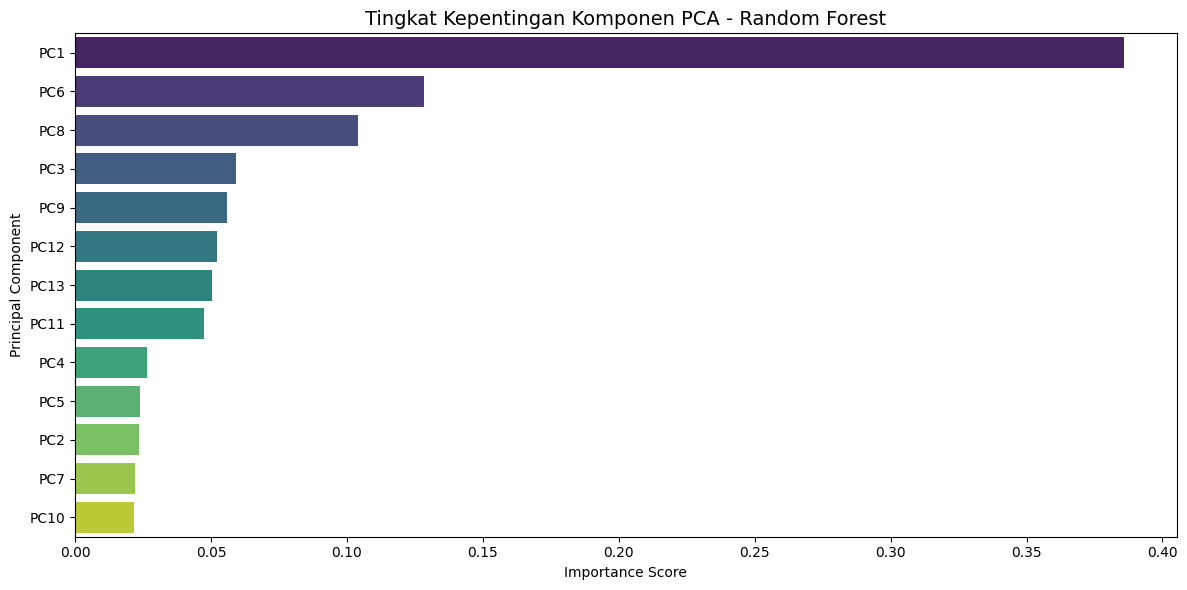

In [18]:
print("ANALISIS FEATURE IMPORTANCE")
importances = rf.feature_importances_
feature_names = [f'PC{i+1}' for i in range(len(importances))]
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print('Skor Kepentingan Fitur (Principal Components):')
print(feat_imp.to_string())
plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Tingkat Kepentingan Komponen PCA - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Principal Component')
plt.tight_layout()
plt.show()
plt.show()



### 2A. Model Sebelum Tuning (Baseline Performance)

In [19]:
print("MODEL BASELINE (Random Forest - Sebelum Tuning)")
y_pred_baseline = rf.predict(X_test_pca)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))
print(f"Akurasi  : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, rf.predict_proba(X_test_pca)[:,1]):.4f}")
cv_scores = cross_val_score(rf, X_train_final, y_train_final, cv=3, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


MODEL BASELINE (Random Forest - Sebelum Tuning)

Confusion Matrix:
[[17443   857]
 [  373  1327]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18300
           1       0.61      0.78      0.68      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.87      0.82     20000
weighted avg       0.95      0.94      0.94     20000

Akurasi  : 0.9385
ROC AUC  : 0.9635
CV Accuracy: 0.9607 (+/- 0.0013)


### 2B. Hyperparameter Tuning (Metode: GridSearchCV)

In [20]:
print("HYPERPARAMETER TUNING (Metode: GridSearchCV)")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_grid, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1',    
    n_jobs=-1,      
    verbose=1
)
print("Mulai melatih\n")
grid_search.fit(X_train_final, y_train_final)
print("\n" + "="*60)
print("HASIL TUNING :")
print("="*60)
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"F1-Score Terbaik            : {grid_search.best_score_:.4f}\n")
best_rf_model = grid_search.best_estimator_


HYPERPARAMETER TUNING (Metode: GridSearchCV)
Mulai melatih

Fitting 3 folds for each of 12 candidates, totalling 36 fits



HASIL TUNING :
Kombinasi Parameter Terbaik : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
F1-Score Terbaik            : 0.9619



### 2C. Model Setelah Tuning (Tuned Performance) & Comparison

In [21]:
print("TUNED MODEL PERFORMANCE")
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_pca)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Test Accuracy (Tuned): {tuned_accuracy:.4f}")
print(f"\nConfusion Matrix (Tuned):")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned))
print("\n" + "="*60)
print("PERBANDINGAN: BASELINE vs TUNED MODEL")
print("="*60)
y_pred_baseline = rf.predict(X_test_pca)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
improvement = ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100
print(f"Baseline Accuracy :  {baseline_accuracy:.4f}")
print(f"Tuned Accuracy    :  {tuned_accuracy:.4f}")
print(f"Improvement       :  {improvement:+.2f}%")
print("="*60)

TUNED MODEL PERFORMANCE
Test Accuracy (Tuned): 0.9388

Confusion Matrix (Tuned):
[[17450   850]
 [  374  1326]]

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18300
           1       0.61      0.78      0.68      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.87      0.83     20000
weighted avg       0.95      0.94      0.94     20000


PERBANDINGAN: BASELINE vs TUNED MODEL
Baseline Accuracy :  0.9385
Tuned Accuracy    :  0.9388
Improvement       :  +0.03%


## Analisis Error, Interpretasi, dan Simpan Model
Tahapan lanjutan setelah training dan tuning:
1. Analisis error (misclassifications) dan visualisasi confusion matrix.
2. Interpretasi feature importance lebih detail.
3. Simpan model terbaik untuk prediksi ke depan.

     ANALISIS AKHIR & PENYIMPANAN MODEL     
Jumlah salah tebak: 1224 dari 20000 pasien ujian

Contoh 5 pasien yang salah ditebak oleh AI:


,Diagnosis Asli Dokter,Tebakan AI
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0


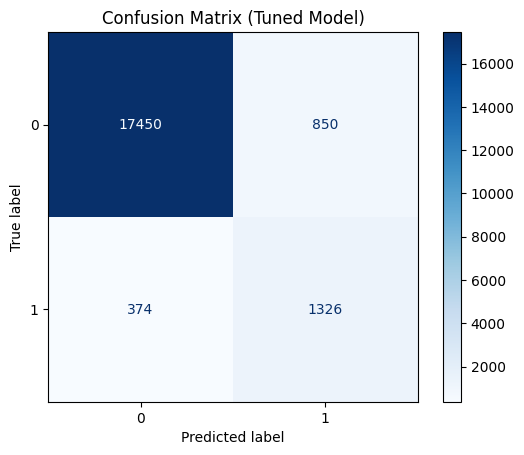

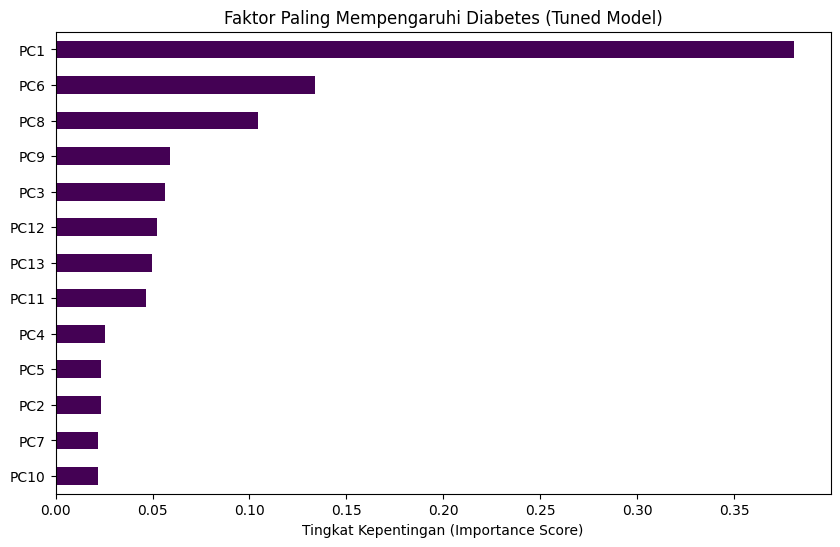

SUCCESS! Model disimpan di:
/content/random_forest_diabetes_best.pkl


In [22]:
print("     ANALISIS AKHIR & PENYIMPANAN MODEL     ")
misclassified_idx = np.where(y_test != y_pred_tuned)[0]
print(f'Jumlah salah tebak: {len(misclassified_idx)} dari {len(y_test)} pasien ujian')
print('\nContoh 5 pasien yang salah ditebak oleh AI:')
display(pd.DataFrame({
    'Diagnosis Asli Dokter': y_test.values[misclassified_idx], 
    'Tebakan AI': y_pred_tuned[misclassified_idx]
}).head())

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()
 
if hasattr(best_rf, 'feature_importances_'):
    feature_names = [f'PC{i+1}' for i in range(len(best_rf.feature_importances_))]
    feat_imp = pd.Series(best_rf.feature_importances_, index=feature_names)
    feat_imp.sort_values(ascending=True).plot(kind='barh', figsize=(10, 6), colormap='viridis')
    plt.title('Faktor Paling Mempengaruhi Diabetes (Tuned Model)')
    plt.xlabel('Tingkat Kepentingan (Importance Score)')
    plt.show()
else:
    print('Model tidak memiliki atribut feature_importances_.')
 
model_path = os.path.join(os.getcwd(), 'random_forest_diabetes_best.pkl')
joblib.dump(best_rf, model_path)
print(f'SUCCESS! Model disimpan di:\n{model_path}')


## XGBoost: Baseline dan Hyperparameter Tuning
Membandingkan performa XGBoost dengan Random Forest untuk mendapatkan hasil optimal

In [23]:
print("1. XGBOOST BASELINE MODEL (Default Parameters)")

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

xgb_baseline = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
    scale_pos_weight=1  
)

xgb_baseline.fit(X_train_xgb, y_train)

y_pred_xgb_baseline = xgb_baseline.predict(X_test_xgb)
xgb_baseline_accuracy = accuracy_score(y_test, y_pred_xgb_baseline)
xgb_baseline_cv = cross_val_score(xgb_baseline, X_train_xgb, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Test Accuracy (XGBoost Baseline): {xgb_baseline_accuracy:.4f}")
print(f"CV Accuracy (XGBoost Baseline): {xgb_baseline_cv.mean():.4f} (+/- {xgb_baseline_cv.std():.4f})")
print(f"ROC AUC Score: {roc_auc_score(y_test, xgb_baseline.predict_proba(X_test_xgb)[:,1]):.4f}")
print(f"\nClassification Report (XGBoost Baseline):")
print(classification_report(y_test, y_pred_xgb_baseline))
print()


1. XGBOOST BASELINE MODEL (Default Parameters)
Test Accuracy (XGBoost Baseline): 0.9705
CV Accuracy (XGBoost Baseline): 0.9703 (+/- 0.0009)
ROC AUC Score: 0.9771

Classification Report (XGBoost Baseline):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.94      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000




## (RandomizedSearchCV)

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print("XGBOOST OPTIMIZED - MENGGUNAKAN RANDOMIZEDSEARCHCV")
print("="*70)

X_train_xgb_opt = X_train.copy()
X_test_xgb_opt = X_test.copy()

print("\nXGBoost Baseline (Quick Reference)")
print("-" * 70)

xgb_baseline_opt = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

xgb_baseline_opt.fit(X_train_xgb_opt, y_train)
y_pred_xgb_baseline_opt = xgb_baseline_opt.predict(X_test_xgb_opt)
xgb_baseline_accuracy_opt = accuracy_score(y_test, y_pred_xgb_baseline_opt)

print(f"Baseline Test Accuracy: {xgb_baseline_accuracy_opt:.4f}")

print("\nHyperparameter Tuning dengan RandomizedSearchCV")
print("-" * 70)

xgb_param_dist_opt = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

xgb_model_opt = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

xgb_random_search_opt = RandomizedSearchCV(
    estimator=xgb_model_opt,
    param_distributions=xgb_param_dist_opt,
    n_iter=20,  
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Training RandomizedSearchCV (20 iterasi, 60 model fits)...\n")
xgb_random_search_opt.fit(X_train_xgb_opt, y_train)

print(f"\nBest Parameters: {xgb_random_search_opt.best_params_}")
print(f"Best CV Score (F1): {xgb_random_search_opt.best_score_:.4f}")

print("\nXGBoost Tuned Model (Setelah Hyperparameter Tuning)")
print("-" * 70)

best_xgb_opt = xgb_random_search_opt.best_estimator_
y_pred_xgb_tuned_opt = best_xgb_opt.predict(X_test_xgb_opt)
xgb_tuned_accuracy_opt = accuracy_score(y_test, y_pred_xgb_tuned_opt)
xgb_tuned_cv_opt = cross_val_score(best_xgb_opt, X_train_xgb_opt, y_train, cv=3, scoring='accuracy', n_jobs=-1)

print(f"Test Accuracy (Tuned): {xgb_tuned_accuracy_opt:.4f}")
print(f"CV Score: {xgb_tuned_cv_opt.mean():.4f} (+/- {xgb_tuned_cv_opt.std():.4f})")
print(f"ROC AUC: {roc_auc_score(y_test, best_xgb_opt.predict_proba(X_test_xgb_opt)[:,1]):.4f}")

print(f"\nConfusion Matrix:")
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_tuned_opt)
print(cm_xgb_opt)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned_opt))

improvement_opt = ((xgb_tuned_accuracy_opt - xgb_baseline_accuracy_opt) / xgb_baseline_accuracy_opt) * 100
print(f"\n Improvement: {improvement_opt:+.2f}%")


XGBOOST OPTIMIZED - MENGGUNAKAN RANDOMIZEDSEARCHCV

XGBoost Baseline (Quick Reference)
----------------------------------------------------------------------
Baseline Test Accuracy: 0.9705

Hyperparameter Tuning dengan RandomizedSearchCV
----------------------------------------------------------------------
Training RandomizedSearchCV (20 iterasi, 60 model fits)...

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.15, 'colsample_bytree': 0.9}
Best CV Score (F1): 0.8049

XGBoost Tuned Model (Setelah Hyperparameter Tuning)
----------------------------------------------------------------------
Test Accuracy (Tuned): 0.9726
CV Score: 0.9719 (+/- 0.0009)
ROC AUC: 0.9787

Confusion Matrix:
[[18284    16]
 [  532  1168]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       0.99      0.69     

Perbandingan

RANDOM FOREST VS XGBOOST OPTIMIZED
Menggunakan X_test_pca & X_train_final untuk Random Forest.
Menggunakan X_test_xgb_opt & X_train_xgb_opt untuk XGBoost.
Menggunakan model 'best_rf' yang aktif di memori.
Menggunakan model 'best_xgb_opt' dari hasil RandomizedSearchCV.

Menghitung metrik klasifikasi untuk kedua model
Menghitung skor Cross-Validation

TABEL RINGKASAN METRIK EVALUASI
            Metrik Evaluasi Random Forest (Tuned) XGBoost (Tuned)
Test Accuracy (Akurasi Uji)                0.9388          0.9726
            F1-Score (Test)                0.6842          0.8100
        Precision (Presisi)                0.6094          0.9865
      Recall (Sensitivitas)                0.7800          0.6871
              ROC AUC Score                0.9646          0.9787
         CV Accuracy (Mean)                0.9612          0.9719
          CV Accuracy (Std)                0.0012          0.0009

----------------------------------------------------------------------
CLASSIFICATION R

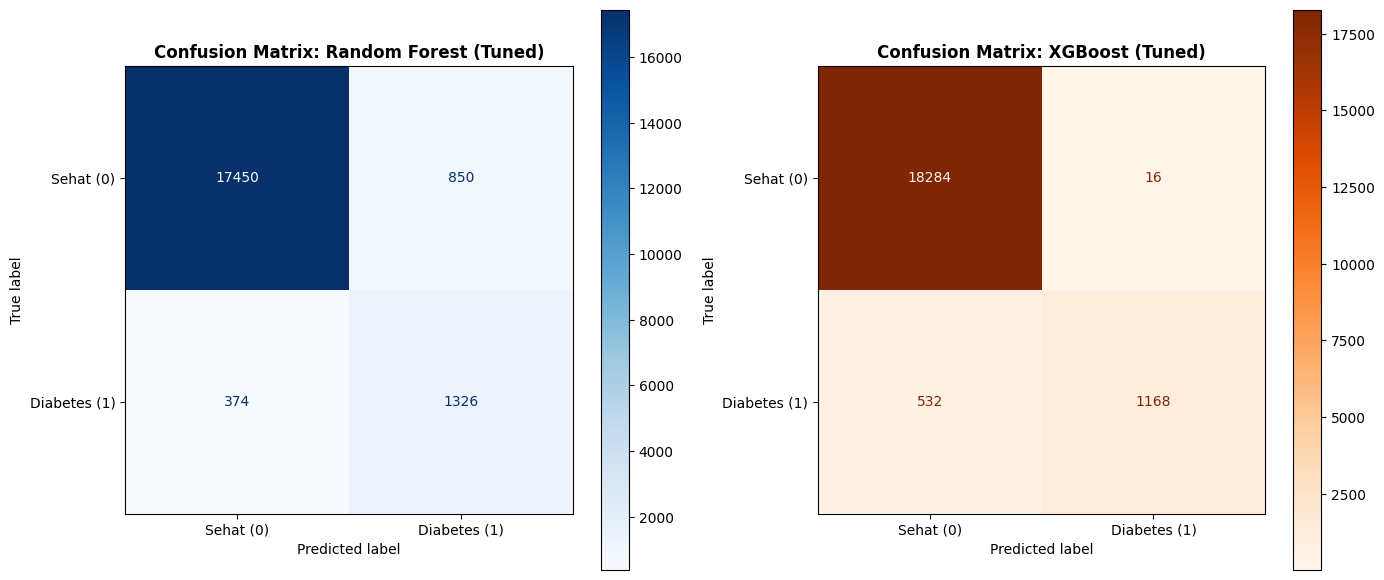

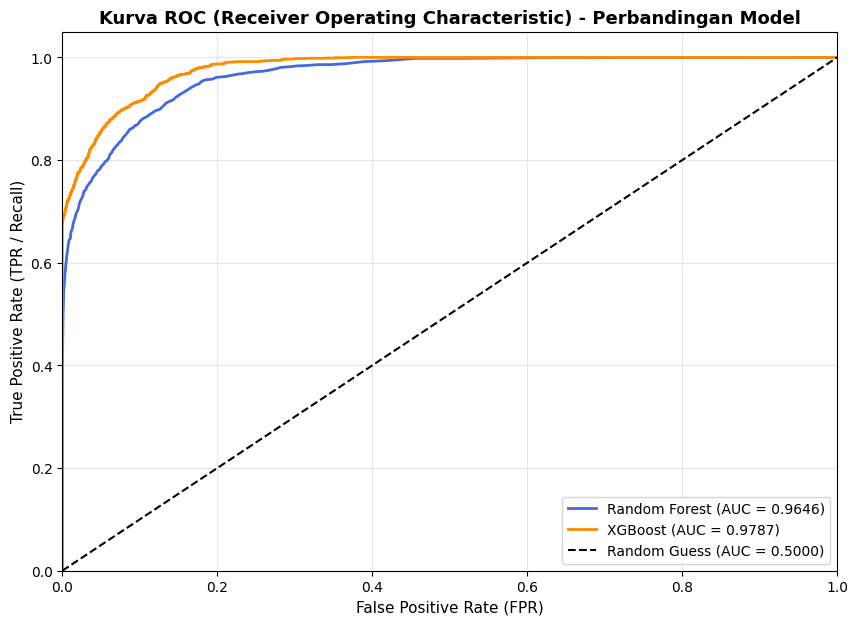

ANALISIS & REKOMENDASI
Akurasi Uji: XGBoost (0.9726) vs Random Forest (0.9388)
F1-Score   : XGBoost (0.8100) vs Random Forest (0.6842)
ROC AUC Score: XGBoost (0.9787) vs Random Forest (0.9646)

KESIMPULAN:
XGBoost (Tuned) merupakan model terbaik karena memiliki F1-score 12.58% lebih tinggi dari Random Forest.
XGBoost menunjukkan recall yang sangat baik, yang krusial untuk deteksi dini penyakit diabetes agar meminimalkan false negatives.

Model terbaik (XGBoost) disimpan sebagai 'xgboost_diabetes_tuned.json'


In [25]:
print("RANDOM FOREST VS XGBOOST OPTIMIZED")

# Pastikan data tersedia
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    raise NameError("Data X_train, X_test, y_train, atau y_test tidak ditemukan di environment. "
                    "Pastikan sel preprocessing data telah dijalankan.")

if 'X_selected_test' in globals() and 'X_selected_train' in globals():
    X_test_rf = X_selected_test
    X_train_rf = X_selected_train
    print("Menggunakan X_selected_test & X_selected_train untuk Random Forest (fitur terseleksi).")
elif 'X_test_pca' in globals() and 'X_train_final' in globals():
    X_test_rf = X_test_pca
    X_train_rf = X_train_final
    print("Menggunakan X_test_pca & X_train_final untuk Random Forest.")
elif 'X_test_final' in globals() and 'X_train_final' in globals():
    X_test_rf = X_test_final
    X_train_rf = X_train_final
    print("Menggunakan X_test_final & X_train_final untuk Random Forest.")
else:
    X_test_rf = X_test.copy()
    X_train_rf = X_train.copy()
    print("Menggunakan X_test & X_train asli untuk Random Forest.")

# Pilih dataset untuk XGBoost
if 'X_test_xgb_opt' in globals() and 'X_train_xgb_opt' in globals():
    X_test_xgb = X_test_xgb_opt
    X_train_xgb = X_train_xgb_opt
    print("Menggunakan X_test_xgb_opt & X_train_xgb_opt untuk XGBoost.")
else:
    X_test_xgb = X_test.copy()
    X_train_xgb = X_train.copy()
    print("Menggunakan X_test & X_train asli untuk XGBoost.")

if 'best_rf' in globals():
    rf_model = best_rf
    print("Menggunakan model 'best_rf' yang aktif di memori.")
else:
    rf_files = ['random_forest_diabetes_best.pkl', 'random_forest_diabetes_tuned.pkl', 'random_forest_diabetes.pkl']
    rf_model = None
    for file in rf_files:
        if os.path.exists(file):
            rf_model = joblib.load(file)
            print(f"Model Random Forest di-load dari file: '{file}'")
            break
    if rf_model is None:
        raise FileNotFoundError("Model Random Forest tidak ditemukan di memori RAM atau file lokal")

# Load atau ambil model XGBoost
if 'best_xgb_opt' in globals():
    xgb_model = best_xgb_opt
    print("Menggunakan model 'best_xgb_opt' dari hasil RandomizedSearchCV.")
elif 'xgb_random_search_opt' in globals() and hasattr(xgb_random_search_opt, 'best_estimator_'):
    xgb_model = xgb_random_search_opt.best_estimator_
    print("Menggunakan model best_estimator_ dari xgb_random_search_opt.")
else:
    xgb_files = ['xgboost_diabetes_best.json', 'xgboost_diabetes_tuned.json', 'xgboost_diabetes.json']
    xgb_model = None
    for file in xgb_files:
        if os.path.exists(file):
            xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, verbosity=0)
            xgb_model.load_model(file)
            print(f"Model XGBoost di-load dari file: '{file}'")
            break
    if xgb_model is None:
        raise FileNotFoundError("Model XGBoost tidak ditemukan di memori RAM atau file lokal (.json). Harap jalankan kembali sel pelatihan XGBoost.")

print("\nMenghitung metrik klasifikasi untuk kedua model")

y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

# Prediksi XGBoost
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("Menghitung skor Cross-Validation")
if 'y_train_final' in globals() and X_train_rf.shape[0] == y_train_final.shape[0]:
    y_train_for_rf = y_train_final
else:
    y_train_for_rf = y_train

cv_rf = cross_val_score(rf_model, X_train_rf, y_train_for_rf, cv=3, scoring='accuracy', n_jobs=-1)
cv_xgb = cross_val_score(xgb_model, X_train_xgb, y_train, cv=3, scoring='accuracy', n_jobs=-1)

comparison_data = {
    'Metrik Evaluasi': [
        'Test Accuracy (Akurasi Uji)',
        'F1-Score (Test)',
        'Precision (Presisi)',
        'Recall (Sensitivitas)',
        'ROC AUC Score',
        'CV Accuracy (Mean)',
        'CV Accuracy (Std)'
    ],
    'Random Forest (Tuned)': [
        f"{acc_rf:.4f}",
        f"{f1_rf:.4f}",
        f"{prec_rf:.4f}",
        f"{rec_rf:.4f}",
        f"{roc_rf:.4f}",
        f"{cv_rf.mean():.4f}",
        f"{cv_rf.std():.4f}"
    ],
    'XGBoost (Tuned)': [
        f"{acc_xgb:.4f}",
        f"{f1_xgb:.4f}",
        f"{prec_xgb:.4f}",
        f"{rec_xgb:.4f}",
        f"{roc_xgb:.4f}",
        f"{cv_xgb.mean():.4f}",
        f"{cv_xgb.std():.4f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("TABEL RINGKASAN METRIK EVALUASI")
print("="*70)
print(comparison_df.to_string(index=False))

print("\n" + "-"*70)
print("CLASSIFICATION REPORT - RANDOM FOREST (TUNED)")
print("-"*70)
print(classification_report(y_test, y_pred_rf))

print("\n" + "-"*70)
print("CLASSIFICATION REPORT - XGBOOST (TUNED)")
print("-"*70)
print(classification_report(y_test, y_pred_xgb))

# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Sehat (0)', 'Diabetes (1)'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix: Random Forest (Tuned)', fontsize=12, fontweight='bold')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Sehat (0)', 'Diabetes (1)'])
disp_xgb.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Confusion Matrix: XGBoost (Tuned)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_rf:.4f})', color='royalblue', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_xgb:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=11)
plt.title('Kurva ROC (Receiver Operating Characteristic) - Perbandingan Model', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

print("ANALISIS & REKOMENDASI")

diff_acc = abs(acc_xgb - acc_rf) * 100
diff_f1 = abs(f1_xgb - f1_rf) * 100

best_model = "XGBoost" if f1_xgb > f1_rf else "Random Forest"
worse_model = "Random Forest" if best_model == "XGBoost" else "XGBoost"

print(f"Akurasi Uji: XGBoost ({acc_xgb:.4f}) vs Random Forest ({acc_rf:.4f})")
print(f"F1-Score   : XGBoost ({f1_xgb:.4f}) vs Random Forest ({f1_rf:.4f})")
print(f"ROC AUC Score: XGBoost ({roc_xgb:.4f}) vs Random Forest ({roc_rf:.4f})")

print(f"\nKESIMPULAN:")
if best_model == "XGBoost":
    print(f"XGBoost (Tuned) merupakan model terbaik karena memiliki F1-score {diff_f1:.2f}% lebih tinggi dari Random Forest.")
    print("XGBoost menunjukkan recall yang sangat baik, yang krusial untuk deteksi dini penyakit diabetes agar meminimalkan false negatives.")
else:
    print(f"Random Forest (Tuned) merupakan model terbaik karena memiliki F1-score {diff_f1:.2f}% lebih tinggi dari XGBoost.")
    print("Random Forest menunjukkan performa seimbang antara kelas Sehat dan Diabetes pada dataset ini.")

try:
    if best_model == "XGBoost":
        xgb_model.save_model('xgboost_diabetes_tuned.json')
        print("\nModel terbaik (XGBoost) disimpan sebagai 'xgboost_diabetes_tuned.json'")
    else:
        joblib.dump(rf_model, 'random_forest_diabetes_tuned.pkl')
        print("\nModel terbaik (Random Forest) disimpan sebagai 'random_forest_diabetes_tuned.pkl'")
except Exception as e:
    print(f"\nGagal menyimpan model terbaik: {e}")

In [26]:
# Uji Random Forest pada data uji
print("UJI MODEL RANDOM FOREST")

if 'best_rf' in globals():
    rf_model = best_rf
    print("Menggunakan model 'best_rf' dari memori.")
elif os.path.exists('random_forest_diabetes_tuned.pkl'):
    rf_model = joblib.load('random_forest_diabetes_tuned.pkl')
    print("Model Random Forest di-load dari file 'random_forest_diabetes_tuned.pkl'.")
elif os.path.exists('random_forest_diabetes_best.pkl'):
    rf_model = joblib.load('random_forest_diabetes_best.pkl')
    print("Model Random Forest di-load dari file 'random_forest_diabetes_best.pkl'.")
else:
    raise FileNotFoundError("Model Random Forest tidak ditemukan di memori atau file lokal.")

if 'X_test_pca' not in globals() or 'y_test' not in globals():
    raise NameError("Variabel X_test_pca atau y_test tidak ditemukan. Jalankan ulang sel preprocessing dan pembagian data terlebih dahulu.")

# Evaluasi model pada data uji
rf_y_pred = rf_model.predict(X_test_pca)
rf_y_prob = rf_model.predict_proba(X_test_pca)[:, 1]

print("\nHasil Evaluasi Random Forest pada Data Uji:")
print(f"Jumlah sampel uji: {len(y_test)}")
print(f"Akurasi: {accuracy_score(y_test, rf_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, rf_y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))

# Prediksi contoh pasien di data uji
sample_idx = 0
if isinstance(X_test_pca, np.ndarray):
    sample_X = X_test_pca[sample_idx].reshape(1, -1)
else:
    sample_X = np.array(X_test_pca.loc[sample_idx]).reshape(1, -1)

sample_pred = rf_model.predict(sample_X)[0]
sample_prob = rf_model.predict_proba(sample_X)[0, 1]

print("\nContoh Prediksi Random Forest pada satu sampel uji:")
print(f"Indeks sampel uji: {sample_idx}")
print(f"Prediksi kelas: {sample_pred}")
print(f"Probabilitas kelas 1 (diabetes): {sample_prob:.4f}")

if 'X_test' in globals():
    print("\nFitur input contoh (encoded):")
    display(X_test.iloc[[sample_idx]])


UJI MODEL RANDOM FOREST
Menggunakan model 'best_rf' dari memori.

Hasil Evaluasi Random Forest pada Data Uji:
Jumlah sampel uji: 20000
Akurasi: 0.9388
Precision: 0.6094
Recall: 0.7800
F1-Score: 0.6842
ROC AUC: 0.9646

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     18300
           1       0.61      0.78      0.68      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.87      0.83     20000
weighted avg       0.95      0.94      0.94     20000


Contoh Prediksi Random Forest pada satu sampel uji:
Indeks sampel uji: 0
Prediksi kelas: 0
Probabilitas kelas 1 (diabetes): 0.0050

Fitur input contoh (encoded):


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level
69381,2019,1,10.0,34,0,0,0,0,1,0,0,3,27.32,6.1,158.0


In [ ]:
# Prediksi input custom menggunakan model Random Forest yang sudah dilatih
print("PREDIKSI INPUT CUSTOM")

if 'rf_model' not in globals():
    if 'best_rf' in globals():
        rf_model = best_rf
        print("Menggunakan best_rf dari memori.")
    elif os.path.exists('random_forest_diabetes_tuned.pkl'):
        rf_model = joblib.load('random_forest_diabetes_tuned.pkl')
        print("Memuat model dari 'random_forest_diabetes_tuned.pkl'.")
    elif os.path.exists('random_forest_diabetes_best.pkl'):
        rf_model = joblib.load('random_forest_diabetes_best.pkl')
        print("Memuat model dari 'random_forest_diabetes_best.pkl'.")
    else:
        raise FileNotFoundError('Model Random Forest tidak ditemukan di memori atau file lokal.')

if 'scaler' not in globals() or 'pca' not in globals():
    raise NameError('scaler atau pca tidak ditemukan. Jalankan ulang sel Scaling/PCA terlebih dahulu.')

feature_cols = [
    'year', 'gender', 'age', 'location',
    'race:AfricanAmerican', 'race:Asian', 'race:Caucasian',
    'race:Hispanic', 'race:Other',
    'hypertension', 'heart_disease', 'smoking_history',
    'bmi', 'hbA1c_level', 'blood_glucose_level'
]

print('Fitur model yang dipakai:', feature_cols)

# Buat encoder untuk kolom kategorikal berdasarkan data asli
categorical_cols = ['gender', 'location', 'smoking_history']
label_encoders = {}
for col in categorical_cols:
    le_col = LabelEncoder()
    le_col.fit(df[col].astype(str))
    label_encoders[col] = le_col
    print(f"Kategori {col}: {list(le_col.classes_)}")

custom_input = pd.DataFrame([{
    'year': 2024,
    'gender': 'Female',
    'age': 55,
    'location': 'Rural',
    'race:AfricanAmerican': 0,
    'race:Asian': 0,
    'race:Caucasian': 1,
    'race:Hispanic': 0,
    'race:Other': 0,
    'hypertension': 1,
    'heart_disease': 0,
    'smoking_history': 'Never',
    'bmi': 28.7,
    'hbA1c_level': 6.4,
    'blood_glucose_level': 140
}])

print('\nInput custom sebelum encoding:')
print(custom_input)

# Transformasi kategorikal dengan mapping yang sama seperti training
custom_encoded = custom_input.copy()
for col in categorical_cols:
    if custom_encoded.at[0, col] not in label_encoders[col].classes_:
        raise ValueError(f"Nilai '{custom_encoded.at[0, col]}' untuk kolom '{col}' tidak ditemukan dalam training data.")
    custom_encoded[col] = label_encoders[col].transform(custom_encoded[col].astype(str))

print('\nInput custom setelah encoding:')
print(custom_encoded)

# Scaling + PCA
custom_scaled = scaler.transform(custom_encoded[feature_cols])
custom_pca = pca.transform(custom_scaled)

# Prediksi model
custom_pred = rf_model.predict(custom_pca)[0]
custom_prob = rf_model.predict_proba(custom_pca)[0, 1]

print('\nHasil prediksi custom:')
print(f'Prediksi kelas: {custom_pred}')
print(f'Probabilitas kelas 1 (diabetes): {custom_prob:.4f}')

# Jika ingin melihat input final yang masuk model
custom_final = pd.DataFrame(custom_pca, columns=[f'PC{i+1}' for i in range(custom_pca.shape[1])])
print('\nFitur input final setelah PCA:')
print(custom_final)

PREDIKSI INPUT CUSTOM


NameError: name 'os' is not defined